In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Create the Taxi environment with text rendering for debugging
env = gym.make("Taxi-v3", render_mode="ansi")

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)


Number of states: 500
Number of actions: 6


In [2]:
def reset_env(env):
    """Reset environment and return only the observation (state id)."""
    obs, info = env.reset()
    return obs

def step_env(env, action):
    """
    Take one step in the environment.
    Returns: next_state, reward, done, info
    """
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    return obs, reward, done, info

def render_env(env):
    """Print the ASCII grid."""
    print(env.render())


In [3]:
action_meaning = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff",
}

for a in range(6):
    print(a, "-", action_meaning[a])


0 - South
1 - North
2 - East
3 - West
4 - Pickup
5 - Dropoff


Random agent - average reward over 100 episodes: -759.3


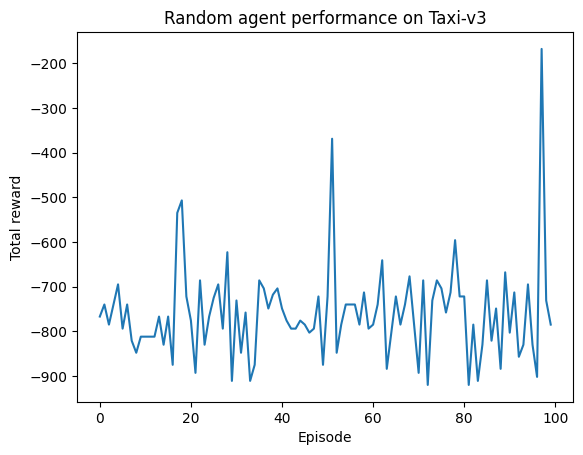

In [4]:
def run_random_agent(env, episodes=100, max_steps=200):
    rewards = []
    for ep in range(episodes):
        state = reset_env(env)
        done = False
        total_reward = 0

        for step in range(max_steps):
            action = env.action_space.sample()
            state, reward, done, info = step_env(env, action)
            total_reward += reward
            if done:
                break

        rewards.append(total_reward)
    return rewards

random_rewards = run_random_agent(env, episodes=100)
print("Random agent - average reward over 100 episodes:", np.mean(random_rewards))

plt.plot(random_rewards)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Random agent performance on Taxi-v3")
plt.show()
